# Лабораторная работа №1
## Первичное исследование и оценка качества данных

**Датасет:** Музеи мира (world_museums_complete.csv)

**Студент:** Рустамова Азиза

## 1. Постановка задачи

### Что это за данные?
Данные о музейной инфраструктуре разных стран мира за разные годы. Содержат общее количество музеев, разбивку по типам (искусство, история, наука), экономические показатели (ВВП на душу, доход от туризма, бюджет на культуру) и число объектов UNESCO.

### Кто заказчик?
Международный совет музеев (ICOM) или аналитический отдел Министерства культуры. Цель — понять факторы, влияющие на развитие музейной сети, и выявить аномалии в данных.

### Задачи ИАД:
1. **Поиск аномалий (выбросов)** — найти страны/годы с нереалистичным количеством музеев (ошибки учёта, дубликаты).
2. **Описательная аналитика** — определить связь между культурным бюджетом, ВВП и числом музеев.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Всё работает! Библиотеки загружены.")

Всё работает! Библиотеки загружены.


In [7]:
# Загрузка данных
df = pd.read_csv('../data/world_museums_complete.csv')

# Проверка
print(f"Загружено строк: {len(df)}")
print(f"Столбцов: {len(df.columns)}")
df.head()

Загружено строк: 520
Столбцов: 12


,country,region,year,total_museums,art_museums,history_museums,science_museums,population_millions,gdp_per_capita_usd,tourism_income_billion,culture_budget_percent,unesco_sites
0,Poland,Europe,2022,2179,517,933,729,363.42,72729,152.70,0.32,9
1,France,Europe,2018,2770,802,1135,833,1327.18,97146,143.80,2.01,5
2,Spain,Europe,2022,5349,817,2096,2436,461.39,69307,187.92,2.32,8
3,Greece,Europe,2020,2050,425,890,735,387.28,47119,52.07,2.44,11
4,Malaysia,Asia,2018,3036,547,1263,1226,484.35,29486,167.48,0.34,3


## 2. Паспорт датасета

In [8]:
# Размер датасета
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

# Типы данных
print("\nТипы признаков:")
print(df.dtypes)

# Статистика по числовым признакам
print("\nСтатистика числовых признаков:")
df.describe()

Количество строк: 520
Количество столбцов: 12

Типы признаков:
country                    object
region                     object
year                        int64
total_museums               int64
art_museums                 int64
history_museums             int64
science_museums             int64
population_millions       float64
gdp_per_capita_usd          int64
tourism_income_billion    float64
culture_budget_percent    float64
unesco_sites                int64
dtype: object

Статистика числовых признаков:


,year,total_museums,art_museums,history_museums,science_museums,population_millions,gdp_per_capita_usd,tourism_income_billion,culture_budget_percent,unesco_sites
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,2019.784615,6195.617308,1494.144231,2743.436538,1958.036538,743.422904,51073.840385,99.228250,1.256269,7.246154
std,2.685821,9255.965024,2299.421885,4148.688347,3107.047342,431.260534,27581.860401,59.431241,0.677981,4.504438
min,2015.000000,50.000000,10.000000,23.000000,10.000000,3.190000,5256.000000,0.710000,0.110000,0.000000
25%,2018.000000,468.750000,115.500000,215.000000,153.000000,374.227500,26360.250000,45.640000,0.680000,3.000000
50%,2020.000000,2933.500000,670.000000,1249.000000,822.500000,741.070000,51238.500000,99.780000,1.195000,7.000000
75%,2022.000000,5917.250000,1495.250000,2661.750000,1808.250000,1140.465000,75725.750000,149.760000,1.840000,11.000000
max,2023.000000,39796.000000,12709.000000,21317.000000,16320.000000,1449.530000,99978.000000,199.430000,2.490000,15.000000


## 3. Аудит качества данных

### 3.1. Пропуски (Missing Values)

In [9]:
# Проверка пропусков
missing = df.isnull().sum()
missing_perc = 100 * missing / len(df)
missing_table = pd.DataFrame({'Пропуски': missing, '% от всех': missing_perc})
missing_table.sort_values('% от всех', ascending=False)

,Пропуски,% от всех
country,0,0.0
region,0,0.0
year,0,0.0
total_museums,0,0.0
art_museums,0,0.0
history_museums,0,0.0
science_museums,0,0.0
population_millions,0,0.0
gdp_per_capita_usd,0,0.0
tourism_income_billion,0,0.0


### 3.2. Дубликаты

In [10]:
# Полные дубликаты строк
full_dups = df.duplicated().sum()
print(f"Полных дубликатов строк: {full_dups}")

# Дубликаты по стране и году
dups_country_year = df.duplicated(subset=['country', 'year']).sum()
print(f"Дубликатов по (country, year): {dups_country_year}")

# Покажем пример, если есть
if dups_country_year > 0:
    dup_example = df[df.duplicated(subset=['country', 'year'], keep=False)].sort_values(['country', 'year']).head(6)
    print("\nПример дубликатов (одинаковые страна и год):")
    display(dup_example)

Полных дубликатов строк: 0
Дубликатов по (country, year): 253

Пример дубликатов (одинаковые страна и год):


,country,region,year,total_museums,art_museums,history_museums,science_museums,population_millions,gdp_per_capita_usd,tourism_income_billion,culture_budget_percent,unesco_sites
308,Argentina,Americas,2021,33736,7567,14040,12129,1385.39,38515,3.37,1.65,7
508,Argentina,Americas,2021,31902,5575,17451,8876,1213.97,14098,10.46,0.26,13
78,Argentina,Americas,2023,6125,1578,2857,1690,861.42,9979,110.82,0.44,1
293,Argentina,Americas,2023,12211,2594,5195,4422,978.43,68720,114.59,0.92,2
380,Argentina,Americas,2023,28872,7585,10409,10878,441.61,69477,147.01,1.70,4
488,Argentina,Americas,2023,6449,2134,3489,826,744.37,54589,80.90,1.22,3


### 3.3. Типические проблемы значений

In [11]:
# Проверка на ноль в total_museums
print(f"Стран с total_museums == 0: {(df['total_museums'] == 0).sum()}")
if (df['total_museums'] == 0).sum() > 0:
    print("\nПримеры строк с total_museums = 0:")
    display(df[df['total_museums'] == 0][['country', 'year', 'total_museums']].head())

# Проверка категориальных признаков на "грязные" значения
print("\n--- Проверка категориальных признаков ---")
for col in ['country', 'region']:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df[col].nunique()}")
    print(f"  Примеры: {df[col].iloc[:3].tolist()}")
    print(f"  Есть лишние пробелы: {df[col].str.strip().ne(df[col]).any()}")

Стран с total_museums == 0: 0

--- Проверка категориальных признаков ---

country:
  Уникальных значений: 58
  Примеры: ['Poland', 'France', 'Spain']
  Есть лишние пробелы: False

region:
  Уникальных значений: 5
  Примеры: ['Europe', 'Europe', 'Europe']
  Есть лишние пробелы: False


### 3.4. Выбросы (Outliers)

Границы нормы: [-7704.0, 14090.0]
Количество выбросов по total_museums: 71

Примеры выбросов:


,country,year,total_museums
9,Canada,2015,29610
10,Canada,2022,17318
16,Cuba,2023,23045
32,Mexico,2018,20068
36,Peru,2023,35698
42,Venezuela,2023,18828
51,Cuba,2021,38301
68,Venezuela,2020,14425
76,Colombia,2018,22702
83,Peru,2023,37765


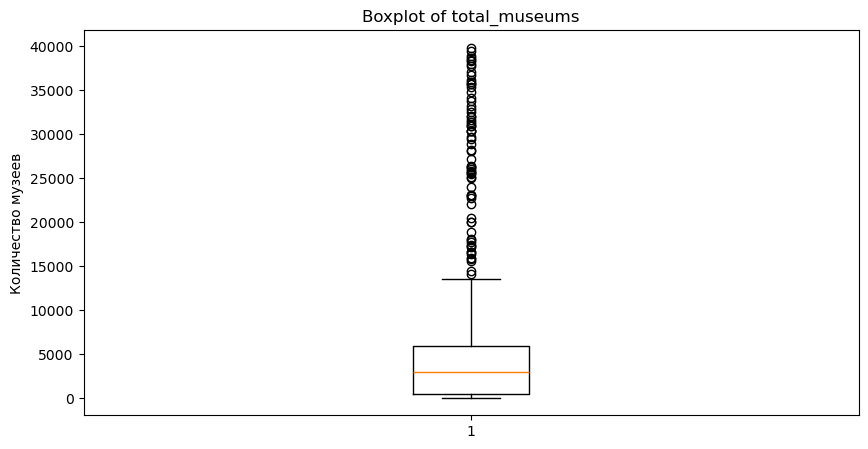

In [12]:
# Метод IQR для total_museums
Q1 = df['total_museums'].quantile(0.25)
Q3 = df['total_museums'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['total_museums'] < lower) | (df['total_museums'] > upper)]
print(f"Границы нормы: [{lower:.1f}, {upper:.1f}]")
print(f"Количество выбросов по total_museums: {len(outliers)}")
print("\nПримеры выбросов:")
display(outliers[['country', 'year', 'total_museums']].head(10))

# Boxplot для визуализации
plt.figure(figsize=(10, 5))
plt.boxplot(df['total_museums'])
plt.title('Boxplot of total_museums')
plt.ylabel('Количество музеев')
plt.show()

## 4. Разведочный анализ (Mini-EDA)

### 4.1. Распределение числового признака (total_museums)

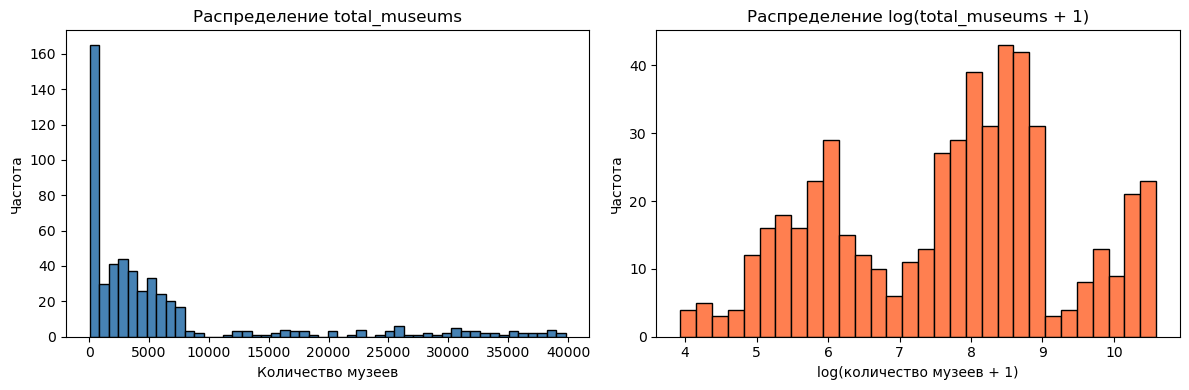

In [13]:
# Гистограмма распределения total_museums
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Обычная шкала
axes[0].hist(df['total_museums'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Распределение total_museums')
axes[0].set_xlabel('Количество музеев')
axes[0].set_ylabel('Частота')

# Логарифмическая шкала (лучше видно)
import numpy as np
log_museums = np.log1p(df['total_museums'])
axes[1].hist(log_museums, bins=30, edgecolor='black', color='coral')
axes[1].set_title('Распределение log(total_museums + 1)')
axes[1].set_xlabel('log(количество музеев + 1)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

### 4.2. Распределение категориального признака (region)

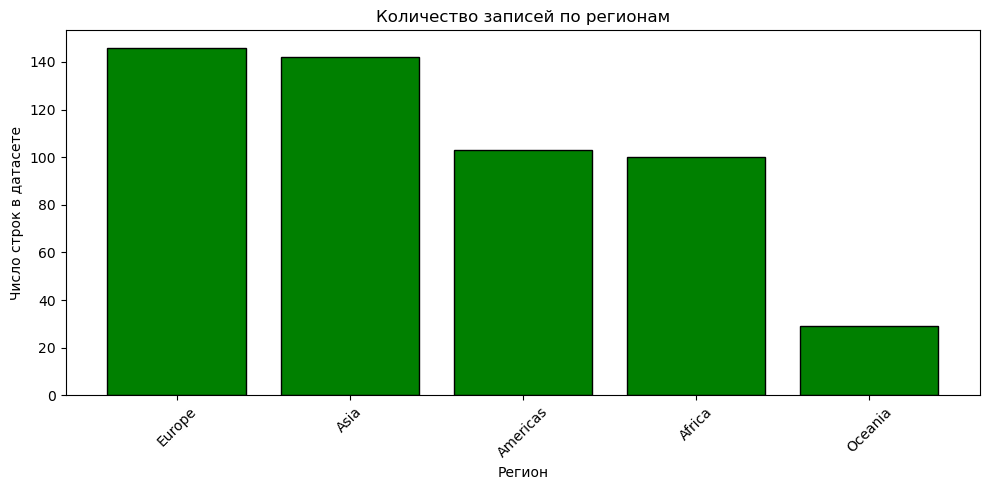

Распределение по регионам (в числах):
region
Europe      146
Asia        142
Americas    103
Africa      100
Oceania      29
Name: count, dtype: int64


In [14]:
# Столбчатая диаграмма по регионам
region_counts = df['region'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(region_counts.index, region_counts.values, color='green', edgecolor='black')
plt.title('Количество записей по регионам')
plt.xlabel('Регион')
plt.ylabel('Число строк в датасете')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Распределение по регионам (в числах):")
print(region_counts)

### 4.3. Зависимость: total_museums vs gdp_per_capita_usd

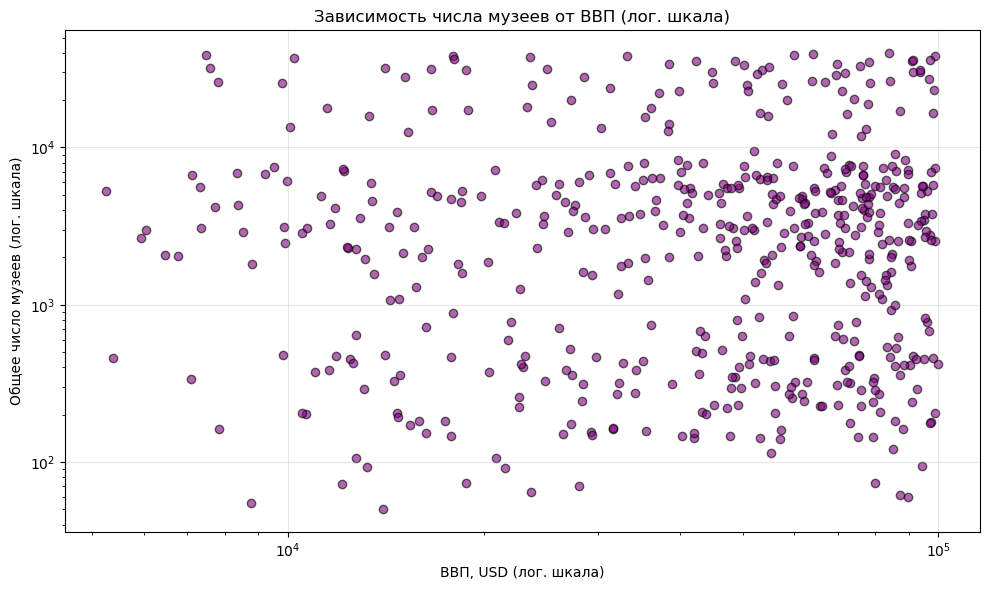

In [16]:
# Точечная диаграмма (scatter plot)
plt.figure(figsize=(10, 6))
plt.scatter(df['gdp_per_capita_usd'], df['total_museums'], alpha=0.6, c='purple', edgecolors='black')
plt.xscale('log')  # логарифмическая шкала для ВВП
plt.yscale('log')  # логарифмическая шкала для музеев
plt.title('Зависимость числа музеев от ВВП (лог. шкала)')
plt.xlabel('ВВП, USD (лог. шкала)')
plt.ylabel('Общее число музеев (лог. шкала)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Краткие выводы по итогам анализа

1. **Пропуски** — отсутствуют, данные предварительно очищены.
2. **Дубликаты** — обнаружены повторяющиеся пары (страна, год), что требует внимания.
3. **Выбросы** — есть страны с аномально высоким числом музеев (более 30 000), возможно, ошибка учёта.
4. **Распределение** — большинство стран имеют до 5 000 музеев, лог-шкала показывает более равномерное распределение.
5. **Регионы** — Европа и Азия представлены чаще всего, Африка и Океания — реже.
6. **Связь ВВП и музеев** — чёткой линейной зависимости не видно, что говорит о влиянии других факторов.